
## Taller Ceros de Funciones.

### Integrantes:

- Valery Monsalve Correa

- Kevin Mateo Gomez Diez

- Heiver David Ruales Luna 

---

## Punto 1.

El volumen V de un líquido contenido en un tanque horizontal cilíndrico de radio r y longitud L
está relacionado con la profundidad del líquido h por:
 $$ V = L[r^2 \cos^{-1}(\frac{r - h}{h}) - (r - h) \sqrt {2rh - h²} ] $$

Para $r = 2 $, $L = 8$ y $V = 12.5m^{3}$. El termino del arco coseno calcular como:

$$ \cos^{-1}(x) = \frac{\pi}{2} - \tan^{-1}(\frac{x}{\sqrt{1-x^2}}) $$

- Realizar el bosquejo de la grafica de la función de ceros
- Determinar h, usando un método abierto
- Determinar h, usando un método cerrado
- De una justificaci´on de su respuesta

### Solución:

Tomamos la funcion y como sabesmos que el volumen es 12.5 entonces hacemos una igualcion

$$ V = 8[2^2 \cos^{-1}(\frac{2 - h}{h}) - (2 - h) \sqrt {2(2)h - h²} ]  = 12.5$$

Despejamos la funcion para tenerla en ceros de funcion
 
$$ f(h) = 8[4 \cos^{-1}(\frac{2 - h}{h}) - (2 - h) \sqrt {4h - h²} ] - 12.5 = 0$$

$$ 0 < h < 2 $$

## Bosquejo de la grafica

/tmp/ipykernel_68590/2827949177.py:17: RuntimeWarning: invalid value encountered in sqrt
  arcos = lambda x : np.pi/2 - np.arctan(x/np.sqrt(1-x**2))


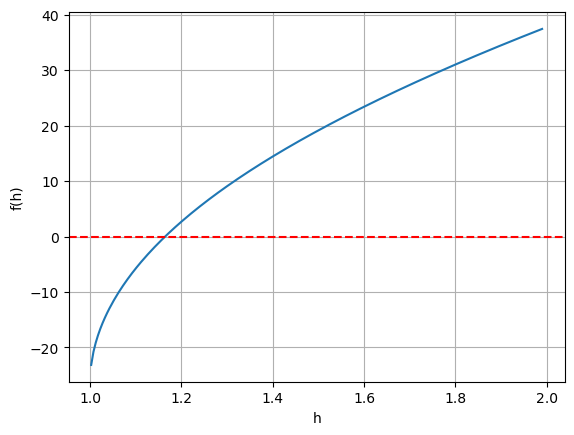

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Realizamos el arreglo de arreglo de los valore para la grafica
# Decidimos este intervalo ya que el enunciado nos dice que el radio
# y la longitud tienen una realacio o mejor dicho tienen una equivalencia
ux = np.linspace(0.01,1.99,400)

# Definimos las variables que nos dan
r = 2
L = 8
V = 12.5

# En el ejercicio nos dicen que el cos^-1(x) para usarlo de manera mas facil
# la definimos como una funcion lambda para poder usarla de manear mas clara
# en la funcion de volumen del tanque cilindrico
arcos = lambda x : np.pi/2 - np.arctan(x/np.sqrt(1-x**2))

# Ahora definimos la funcion f(h) = 0 aqui ya tenermos la funcion despejada
# desde la funcion de volumen(V) llevandolo a la funcion de ceros de funcion
f = lambda h : L*(r**2*arcos((r-h)/h) - (r-h)*np.sqrt(2*r*h-h**2)) - V

# Hacemos una definicion de los valores en que se usaran en la grafica
# tambien trazamos una linea en y=0 aqui es donde veremos por donde
# realizar la aprocimacion en nuestras funciones de ceros de funcion
# osea el intervalo [a,b]
plt.plot(ux, f(ux),label=f)
plt.axhline(0,linestyle="--", color='red')
plt.xlabel('h')
plt.ylabel('f(h)')
plt.grid()
plt.show()

## Metodo por biseccion

In [19]:
from ceros import biseccion
import numpy as np

r = 2
L = 8
V = 12.5

arcos = lambda x : np.pi/2 - np.arctan(x/np.sqrt(1-x**2))
f = lambda h : L*(r**2*arcos((r-h)/h) - (r-h)*np.sqrt(2*r*h-h**2)) - V

por_bisseccion = biseccion(f,1.15,1.2,1e-6)
print(f"El valor de h mas cercano para f(h)=0 es h = {por_bisseccion[0]}\ntomo {por_bisseccion[1]} iteraciones\n")

print(f"Verificamos la solucion {f(por_bisseccion[0])} esto es muy cercano a cero es aproximadamente 0.00005516379...")

El valor de h mas cercano para f(h)=0 es h = 1.1643196105957032
tomo 16 iteraciones

Verificamos la solucion 5.516379235004365e-05 esto es muy cercano a cero es aproximadamente 0.00005516379...


## Metodo por Newton

In [20]:
from ceros import Newton
import sympy as sp 

x = sp.symbols('x')

f_newton = L*(r**2 * (sp.pi/2 - sp.atan(((r-x)/x)/sp.sqrt(1-((r-x)/x)**2))) - (r-x)*sp.sqrt(2*r*x-x**2)) - V

por_newton = Newton(f_newton,1.2,1e-6)
print(f"El valor de h mas cercano para f(h)=0 por Newton es h = {por_newton[0]}\ntomo {por_newton[1]} iteraciones\n")

print(f"Verificamos la solucion {sp.lambdify(x,f_newton)(por_newton[0])} como vemos dio exatamente 0")

El valor de h mas cercano para f(h)=0 por Newton es h = 1.1643189146299515
tomo 4 iteraciones

Verificamos la solucion 0.0 como vemos dio exatamente 0


## Justificacion

- Se utiliza la función de ceros f(h)=V(h)−12.5 porque permite encontrar el valor exacto de la profundidad h donde el volumen calculado coincide con el volumen solicitado.

- Se empleó el método de Bisección debido a que, al trabajar en un intervalo cerrado [0,r], garantiza la convergencia hacia la raíz física real, evitando valores fuera de los límites del tanque.

---


## Punto 2.

La ecuación de Ergun, que se da abajo, sirve para describir el flujo de un líquido a través de un lecho empacado. ΔP es la caída de presión, ρ es la densidad del fluido, G₀ es la velocidad másica (el cociente del flujo de masa dividido entre el área de la sección transversal), Dₚ es el diámetro de las partículas dentro del lecho, μ es la viscocidad del fluido, L es la longitud del lecho y ε es la fracción vacía del lecho.

$$\frac{\Delta P \cdot \rho \cdot D_p}{G_o^2 \cdot L}\frac{\varepsilon^3}{(1-\varepsilon)} = 150 \frac{(1-\varepsilon)}{D_p G_o / \mu} + 1.75$$

1. Realizar el bosquejo de la grafica de la funcion de ceros

2. Dados los siguientes valores para los parametros encuentre la fraccion vacıa ε del lecho, use
el metodo de Biseccion.
- $\frac{D_p G_o}{\mu} = 1000$
- $\frac{\Delta P \cdot \rho \cdot D_p}{G_o^2 \cdot L} = 10$

3. Dados los siguientes valores para los parametros encuentre la fraccion vacıa ε del lecho, use
el metodo de la Secante.
- $\frac{D_p G_o}{\mu} = 1000$
- $\frac{\Delta P \cdot \rho \cdot D_p}{G_o^2 \cdot L} = 10$

4. De una justificacion de su respuesta

### Solución:

### Formulación de la función de ceros

Sustituyendo los valores dados en la ecuación de Ergun:

$$10 \cdot \frac{\varepsilon^3}{1-\varepsilon} = 150 \cdot \frac{1-\varepsilon}{1000} + 1.75$$

Simplificando:

$$10 \cdot \frac{\varepsilon^3}{1-\varepsilon} = 0.15(1-\varepsilon) + 1.75$$

La función de ceros es:

$$f(\varepsilon) = 10 \cdot \frac{\varepsilon^3}{1-\varepsilon} - 0.15(1-\varepsilon) - 1.75 = 0$$

Donde $0 < \varepsilon < 1$ (fracción vacía debe estar entre 0 y 1).

### Justificación del intervalo (0 < ε < 1)

El parámetro $\varepsilon$ representa la **fracción vacía del lecho**, es decir, la proporción de espacio vacío respecto al volumen total.

Se define como:

$$
\varepsilon = \frac{V_{vacío}}{V_{total}}
$$

Por esta definición:

- $\varepsilon = 0$ → no hay espacio vacío (todo son partículas).
- $\varepsilon = 1$ → todo es espacio vacío.

Por lo tanto, el valor de $\varepsilon$ siempre cumple:

$$
0 < \varepsilon < 1
$$

In [21]:
f = lambda e: 10*((e**3)/(1-e))-0.15*(1-e)-1.75
print("Evaluación de la función en algunos puntos:")
for eps in [0.3, 0.4, 0.45, 0.5, 0.6]:
    print(f"f({eps}) = {f(eps)}")

Evaluación de la función en algunos puntos:
f(0.3) = -1.4692857142857143
f(0.4) = -0.7733333333333329
f(0.45) = -0.17568181818181827
f(0.5) = 0.6749999999999998
f(0.6) = 3.59


### Bosquejo de la gráfica

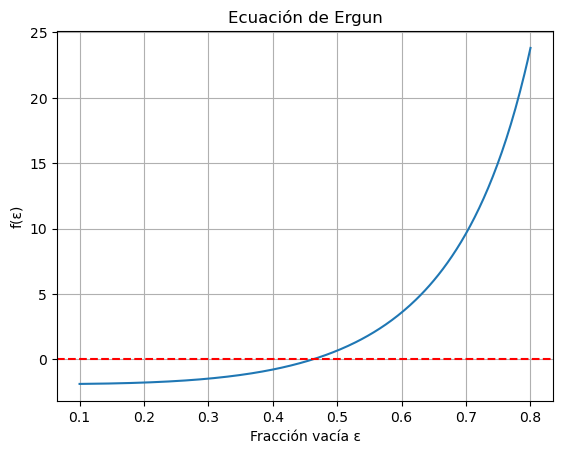

In [22]:
import numpy as np
import matplotlib.pyplot as plt

epsilon = np.linspace(0.1, 0.8, 300)
y = f(epsilon)

plt.plot(epsilon, y)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fracción vacía ε')
plt.ylabel('f(ε)')
plt.title('Ecuación de Ergun')
plt.grid()
plt.show()

### Solución usando el Método de Bisección

La bisección encuentra una raíz dividiendo repetidamente un intervalo donde la función cambia de signo.

Aplicamos el método de bisección con el intervalo identificado en la gráfica.
Usamos la función `biseccion`.

In [23]:
from ceros import biseccion

resultado = biseccion(f, 0.1, 0.9, 1e-6)
print(f"La solucion de la funcion es: {resultado[0]}")

La solucion de la funcion es: 0.4618568420410156


### Solución usando el Método de la Secante

El método de la secante es similar al de Newton-Raphson, pero aproxima la derivada usando dos puntos anteriores, evitando así el cálculo explícito de f'(x).

Fórmula iterativa:
$$x_{n+1} = x_n - f(x_n) \cdot \frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})}$$

Aplicamos el método de la secante con dos valores iniciales cercanos a la raíz.

In [24]:
from ceros import secante

resultado = secante(f, 0.4, 0.5, 1e-6)
print(f"La solucion de la funcion es: {resultado}")

La solucion de la funcion es: 0.46185628340317


### Justificación de la respuesta

Con la función
$$
f(\varepsilon)=10\frac{\varepsilon^3}{1-\varepsilon}-0.15(1-\varepsilon)-1.75, \quad 0<\varepsilon<1
$$
se obtuvo numéricamente una raíz aproximada
$$
\varepsilon \approx 0.462
$$

**Verificación numérica**
Al reemplazar $\varepsilon = 0.462$, se obtiene $f(\varepsilon) \approx 0$.
El residuo es muy pequeño (del orden de la tolerancia usada), por lo que satisface la ecuación de Ergun.

**Consistencia entre métodos**
- Bisección y secante convergen al mismo valor aproximado de $\varepsilon$.
- Esto respalda que la solución encontrada es estable y correcta.

**Justificación matemática de unicidad en el intervalo físico**
En $0<\varepsilon<1$:
$$
f'(\varepsilon)=10\frac{\varepsilon^2(3-2\varepsilon)}{(1-\varepsilon)^2}+0.15>0
$$
Luego, $f$ es estrictamente creciente en todo el intervalo físico, así que solo existe una raíz en $(0,1)$.

Por tanto, la fracción vacía del lecho queda justificada como:
$$
\boxed{\varepsilon \approx 0.462}
$$

---

## Punto 3.

Un cable en forma catenaria es aquel que cuelga entre dos puntos que no se encuentran sobre la
misma línea vertical. Como se ilustra en la figura (a), no está sujeta a más carga que su propio
peso. Ası, su peso (N/m) actúa como una carga uniforme por unidad de longitud a lo largo del
cable. En la figura (b), se ilustra un diagrama de cuerpo libre de una sección AB, donde $T_A$ y $T_B$

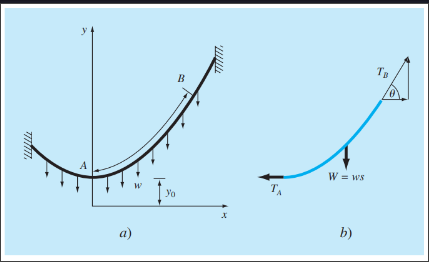

son las fuerzas de tensión en el extremo. Con base en los balances de fuerzas horizontal y vertical,
se obtiene para el cable el siguiente modelo de ecuación diferencial:

$$ \frac{d²y}{dx²} = \frac{\omega}{T_A} \sqrt{1 + (\frac{dy}{dx})²} $$

Puede emplearse el cálculo para resolver esta ecuación para la altura y del cable como función de
la distancia x.

$$ y = \frac{T_A}{\omega} \cosh(\frac{\omega}{T_A} x) + y_0 - \frac{T_A}{\omega} $$



donde el coseno hiperbólico se calcula por medio de la ecuación:

$$ \cosh x = \frac{e^x + e^{-x}}{2}$$

- Realizar el bosquejo de la gráfica de la función de ceros
- Utilice un método para calcular un calor para el parámetro $T_A$ dados los valores de los parámetros $\omega = 12$ y $y_0 = 6$ de modo que el cable tenga una altura de $y = 15$ en $x = 50$
- De una justificación de su respuesta

# Primeros pasos para solucionar 
Tenemos la funcion de la altura del cable:

$$ y = \frac{T_A}{\omega} \cosh(\frac{\omega}{T_A} x) + y_0 - \frac{T_A}{\omega} $$

Con los parámetros dados:
- $\omega = 12$ N/m
- $y_0 = 6$ m
- $y = 15$ m cuando $x = 50$ m

Realizamos una sustitucion de los valores:

$$ 15 = \frac{T_A}{12} \cosh(\frac{12}{T_A} 50) + 6 - \frac{T_A}{12} $$

$$ f(T_A) = \frac{T_A}{12} \cosh(\frac{12}{T_A} 50) + 6 - \frac{T_A}{12} - 15 $$

$$ f(T_A) = \frac{T_A}{12} \cosh(\frac{600}{T_A}) - \frac{T_A}{12} - 9 = 0$$

## Bosquejo de la grafica

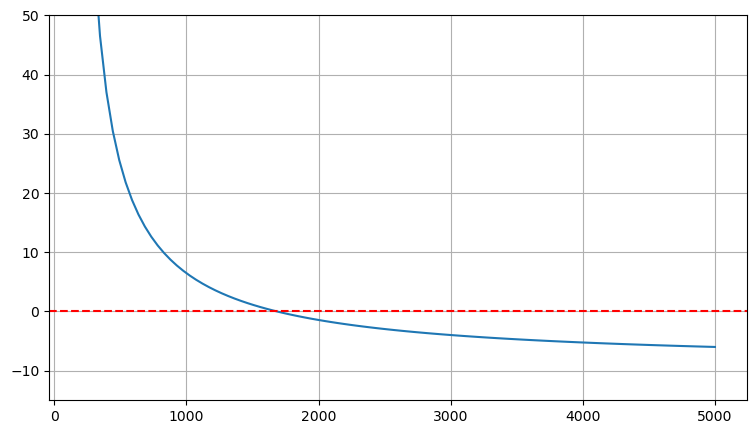

In [25]:
import numpy as np
import matplotlib.pyplot as plt

omega = 12

cosh = lambda x : (np.exp(x) + np.exp(-x))/2 
f = lambda T : T/omega * cosh(600/T) - T/12 -9

ux = np.linspace(200,5000,100)
plt.figure(figsize=(9,5))
plt.plot(ux, f(ux))
plt.axhline(0,linestyle="--", color='red')
plt.ylim(-15,50)
plt.grid()
plt.show()

## Metodo por Biseccion

In [26]:
from ceros import biseccion
import numpy as np

cosh = lambda x : (np.exp(x) + np.exp(-x))/2 
f = lambda T : T/12 * cosh(600/T) - T/12 -9

por_bisseccion = biseccion(f,1500,1900,1e-6)

print(f"El valor de h mas cercano para f(h)=0 es h = {por_bisseccion[0]}\ntomo {por_bisseccion[1]} iteraciones\n")

print(f"Verificamos la solucion {f(por_bisseccion[0])} esto es muy cercano a cero es aproximadamente 0.000000082...")

El valor de h mas cercano para f(h)=0 es h = 1684.3650817871094
tomo 19 iteraciones

Verificamos la solucion 8.200547085834842e-08 esto es muy cercano a cero es aproximadamente 0.000000082...


## Metodo por Newton

In [27]:
from ceros import Newton
import sympy as sp
x = sp.symbols('x')

f_newton = x/12 * (sp.exp(600/x) + sp.exp(-600/x))/2 - x/12 - 9

por_newton = Newton(f_newton,1500,1e-6)

print(f"El valor de h mas cercano para f(h)=0 por Newton es h = {por_newton[0]}\ntomo {por_newton[1]} iteraciones\n")

print(f"Verificamos la solucion {sp.lambdify(x,f_newton)(por_newton[0])} como vemos esto es extremadamente pequeño\no mejor dicho mucho mas aproximado a cero que la biseccion")

El valor de h mas cercano para f(h)=0 por Newton es h = 1684.3650968173688
tomo 5 iteraciones

Verificamos la solucion 2.842170943040401e-14 como vemos esto es extremadamente pequeño
o mejor dicho mucho mas aproximado a cero que la biseccion


## Justificacion

- La variable TA​ no se puede despejar de forma algebraica porque aparece tanto de forma lineal como dentro de una función trascendente (cosh). Por lo tanto, el uso de métodos numéricos es la única vía para hallar su valor.

- El valor obtenido para TA​ asegura que, bajo el peso propio del cable (ω=12), se cumpla la restricción geométrica de alcanzar una altura de 15 metros a una distancia de 50 metros, manteniendo el equilibrio estático del sistema.

---

## Punto 4.

Descomponga en fracciones parciales las siguientes funciones racionales

$$
F(s)=\frac{52.5s(s+1)(s+1.5)(s+5)}{s^4+20.75s^3+92.6s^2+73.69s}
$$

es decir, determine las raíces utilizando un método de búsqueda de raíces, use los 4 métodos para determinar una raíz diferente.

### Solución:

### Definición de la función

La función dada en el ejercicio es:

$$
F(s)=\frac{52.5s(s+1)(s+1.5)(s+5)}{s^4+20.75s^3+92.6s^2+73.69s}
$$

Para encontrar las raíces utilizando métodos numéricos, primero debemos analizar **el denominador de la función**.

Esto se debe a que las raíces del denominador corresponden a los valores de \(s\) que hacen que:

$$
s^4+20.75s^3+92.6s^2+73.69s = 0
$$

Por lo tanto, se define esta expresión como una función \(f(s)\), la cual será utilizada para aplicar los métodos numéricos de búsqueda de raíces (Bisección, Falsa Posición y Newton).

Esta función se define en Python para poder evaluarla en distintos valores de \(s\).

In [28]:
import importlib
import ceros
importlib.reload(ceros)
from ceros import *

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

f= lambda s: (s**4) + (20.75)*s**3 + (92.6)*s**2 + (73.69)*s


### Gráfica de la función

Es útil observar cómo se comporta la función.  
Para esto se realiza una gráfica del denominador de la función.

La gráfica nos ayuda a identificar aproximadamente en qué valores de \(s\) la función
puede cruzar el eje \(x\). Cuando la gráfica cruza el eje \(x\), significa que la función
toma el valor cero en ese punto, es decir, que allí existe una raíz.

Con esta gráfica podemos tener una primera idea de dónde buscar las raíces y así elegir
intervalos adecuados para aplicar los métodos numéricos.

(-10.0, 200.0)

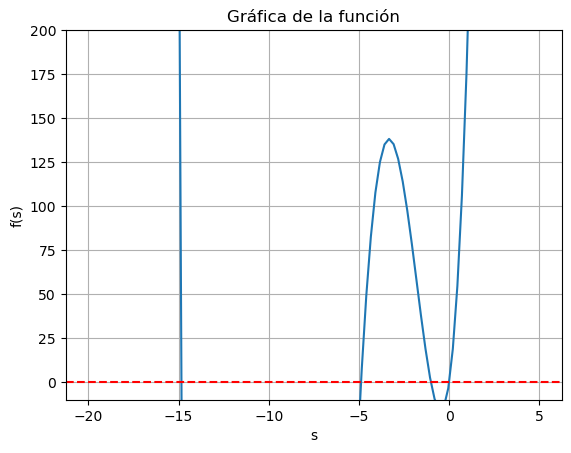

In [29]:
ux = np.linspace(-20,5,100)

plt.plot(ux,f(ux))
plt.axhline(0,linestyle="--",color="red")

plt.title("Gráfica de la función")
plt.xlabel("s")
plt.ylabel("f(s)")
plt.grid()
plt.ylim(-10,200)

### Tabla de valores

Después de observar la gráfica, se evalúa la función en varios valores de \(s\).
Esto se hace para ver con más claridad en qué intervalos la función cambia de signo.

Cuando la función cambia de signo entre dos valores consecutivos, significa que
entre esos dos puntos debe existir una raíz.

Por ejemplo, si en un punto la función es positiva y en el siguiente es negativa,
entonces la función tuvo que pasar por cero en algún punto entre ellos.

Esto permite identificar intervalos donde se pueden aplicar los métodos numéricos
como bisección o falsa posición.

In [30]:
print("   x        f(x)")
print("----------------------")

for i in range(-20,5):
    print(f"{i:>5}   {f(i):>10.2f}")

   x        f(x)
----------------------
  -20     29566.20
  -19     20025.24
  -18     12637.98
  -17      7084.92
  -16      3070.56
  -15       323.40
  -14     -1404.06
  -13     -2335.32
  -12     -2669.88
  -11     -2583.24
  -10     -2226.90
   -9     -1728.36
   -8     -1191.12
   -7      -694.68
   -6      -294.54
   -5       -22.20
   -4       114.84
   -3       133.08
   -2        73.02
   -1        -0.84
    0         0.00
    1       188.04
    2       699.78
    3      1695.72
    4      3360.36


### Identificación de intervalos con raíces

Al observar los valores obtenidos en la tabla se pueden notar algunos cambios de signo.
Estos cambios indican que existe una raíz entre esos dos valores.

Los intervalos donde ocurre esto son:

- entre -15 y -14  
- entre -5 y -4  
- entre -2 y -1  

Además, se puede observar que:

\(f(0) = 0\)

lo que significa que \(s = 0\) también es una raíz de la función.

Estos intervalos se utilizarán para aplicar los métodos numéricos y encontrar
aproximaciones de las raíces.

### Método de Bisección

El método de bisección consiste en tomar un intervalo donde la función cambie de signo.
Si la función es positiva en un punto y negativa en otro, significa que en algún lugar
entre esos dos valores la función debe ser cero, es decir, que hay una raíz.

Según la tabla de valores calculada anteriormente se observa que:

- \(f(-2) < 0\)
- \(f(-1) > 0\)

Esto indica que entre -2 y -1 existe una raíz.

El método de bisección funciona tomando el punto medio del intervalo y evaluando la función
en ese punto. Dependiendo del signo obtenido, se reduce el intervalo a la mitad y se repite
el proceso hasta encontrar una aproximación de la raíz con el error deseado.

In [31]:
raiz_bis= biseccion(f,-2,-1,1e-6)

print("Raiz biseccion:",raiz_bis[0])


Raiz biseccion: -1.0156068801879883


### Método de Falsa Posición

El método de falsa posición es parecido al de bisección porque también utiliza
un intervalo donde la función cambia de signo.

La diferencia es que en lugar de tomar el punto medio del intervalo,
este método calcula un punto donde una recta que une los dos extremos
del intervalo cruza el eje \(x\).

Este punto suele estar más cerca de la raíz que el punto medio,
por lo que en muchos casos el método puede acercarse más rápido
a la solución.

Para este método se utiliza el intervalo donde se observó otro cambio
de signo en la tabla de valores.

In [32]:
raiz_fp = pos_falsa(f,-5,-4,1e-6)

print("Raiz falsa posicion:",raiz_fp[0])


Raiz falsa posicion: -4.886840128741955


### Iteraciones manuales

Se desea aproximar una raíz de la función

$$
f(s)=s^4+20.75s^3+92.6s^2+73.69s
$$

utilizando el método de la falsa posición.

En el algoritmo implementado en Python se utiliza como criterio de parada:

$$
|f(p)| < 10^{-3}
$$

Por lo tanto, en cada iteración se evalúa el valor de \(f(p)\) para verificar
si se cumple la tolerancia establecida.

### Fórmula del método de falsa posición

La aproximación de la raíz se calcula mediante

$$
p=b-f(b)\frac{a-b}{f(a)-f(b)}
$$


### Verificación del intervalo inicial

Se utiliza el intervalo

$$
[a,b]=[-5,-4]
$$

Evaluamos la función en los extremos.

#### Evaluación en \(a=-5\)

$$
f(-5)=(-5)^4+20.75(-5)^3+92.6(-5)^2+73.69(-5)
$$

$$
f(-5)=625-2593.75+2315-368.45
$$

$$
f(-5)=-22.2
$$


#### Evaluación en \(b=-4\)

$$
f(-4)=(-4)^4+20.75(-4)^3+92.6(-4)^2+73.69(-4)
$$

$$
f(-4)=256-1328+1481.6-294.76
$$

$$
f(-4)=114.84
$$

Como

$$
f(-5)f(-4)<0
$$

se concluye que existe al menos una raíz dentro del intervalo.


### Iteración 1

Valores iniciales:

$$
a=-5
$$

$$
b=-4
$$

$$
f(a)=-22.2
$$

$$
f(b)=114.84
$$

Aplicando la fórmula:

$$
p=-4-114.84\frac{-5-(-4)}{-22.2-114.84}
$$

$$
p=-4-114.84\frac{-1}{-137.04}
$$

$$
p=-4-0.8380
$$

$$
p=-4.8380
$$


### Evaluación de la función

$$
f(-4.8380)\approx -4.78
$$

Ahora se verifica la tolerancia:

$$
|f(-4.8380)|=4.78
$$

Como

$$
4.78 > 10^{-3}
$$

no se cumple la tolerancia, por lo que el método debe continuar.

Revisamos el signo:

$$
f(-5)=-22.2
$$

$$
f(-4.8380)=-4.78
$$

Como ambos valores tienen el mismo signo, se actualiza el extremo izquierdo.

Nuevo intervalo:

$$
a=-4.8380
$$

$$
b=-4
$$


### Iteración 2

Ahora se utilizan los nuevos valores:

$$
a=-4.8380
$$

$$
b=-4
$$

$$
f(a)=-4.78
$$

$$
f(b)=114.84
$$

Aplicando nuevamente la fórmula:

$$
p=-4-114.84\frac{-4.8380-(-4)}{-4.78-114.84}
$$

$$
p=-4-114.84\frac{-0.8380}{-119.62}
$$

$$
p=-4-0.8045
$$

$$
p=-4.8045
$$


### Evaluación de la función

$$
f(-4.8045)\approx -7.29
$$

Se verifica la tolerancia:

$$
|f(-4.8045)|=7.29
$$

Como

$$
7.29 > 10^{-3}
$$

la tolerancia aún no se cumple, por lo que el método debería continuar iterando.



**Entonces**, después de realizar dos iteraciones manuales del método de la falsa posición, se obtiene la aproximación

$$
s\approx -4.8045
$$

Sin embargo, como el valor de

$$
|f(p)|
$$

aún es mayor que la tolerancia

$$
10^{-3}
$$

el método debe continuar iterando hasta cumplir el criterio de parada establecido en el algoritmo.

---

### Método de Newton

Este es otro método numérico utilizado para encontrar
raíces de una función. A diferencia de los métodos de bisección y falsa
posición, este método no utiliza un intervalo sino un valor inicial
cercano a la raíz.

La idea del método es utilizar la derivada de la función para construir
la recta tangente en un punto de la curva. Luego se calcula el punto
donde esa recta tangente corta el eje \(x\), y ese punto se toma como
una nueva aproximación de la raíz.

Este proceso se repite varias veces hasta que la diferencia entre dos
aproximaciones consecutivas sea menor que la tolerancia establecida.

En este ejercicio se observó que el denominador de la función es

$$
s^4 + 20.75s^3 + 92.6s^2 + 73.69s
$$

Si se factoriza \(s\), se obtiene

$$
s(s^3 + 20.75s^2 + 92.6s + 73.69)
$$

De esta forma se puede ver que uno de los factores es \(s\), lo que
implica que la función tiene una raíz exacta en

$$
s = 0
$$

Por esta razón se eligió un valor inicial cercano a esta raíz para
aplicar el método de Newton. En este caso se tomó como valor inicial

$$
x_0 = 1
$$

ya que es un valor cercano a \(0\) y permite que el método converja
rápidamente hacia esta raíz.

In [33]:
x = sp.symbols('x')
f_sym = (x**4) + (20.75)*x**3 + (92.6)*x**2 + (73.69)*x

raiz_newton = Newton(f_sym,1,1e-6)

print("Raiz newton:",raiz_newton[0])


Raiz newton: 9.27843322229286e-15


### Método de la Secante

Este método es similar al método de Newton, pero
tiene la ventaja de que no es necesario calcular la derivada de la función.

En lugar de utilizar la derivada, el método utiliza dos valores iniciales
\(x_0\) y \(x_1\). Con estos dos puntos se traza una recta que pasa por
los valores de la función en esos puntos. Luego se calcula el punto donde
esa recta corta el eje \(x\), y ese punto se toma como una nueva
aproximación de la raíz.

El proceso se repite utilizando siempre los dos últimos valores
calculados hasta que la diferencia entre dos aproximaciones
consecutivas sea menor que la tolerancia establecida.

Observando la tabla de valores obtenida anteriormente se identifica
un cambio de signo entre -15 y -14, lo que indica que en ese intervalo
existe una raíz.

Por esta razón se utilizan como valores iniciales:
$$
x_0 = -15
$$
$$
x_1 = -14
$$
A partir de estos valores el método calcula aproximaciones sucesivas
de la raíz hasta cumplir la condición de tolerancia.

In [34]:
raiz_sec = secante(f,-15,-14,1e-6)

print("Raiz secante:",raiz_sec)

Raiz secante: -14.847553221029768


### Descomposición en fracciones parciales

Una vez encontradas las raíces del denominador utilizando los métodos
numéricos, es posible escribir el denominador de la función en forma
factorizada.

A partir de los métodos aplicados anteriormente se obtuvieron las
siguientes raíces aproximadas:

$$
s_1 = 0
$$

$$
s_2 \approx -1.015
$$

$$
s_3 \approx -4.886
$$

$$
s_4 \approx -14.86
$$

Con estas raíces, el denominador del polinomio

$$
s^4 + 20.75s^3 + 92.6s^2 + 73.69s
$$

puede escribirse aproximadamente como el producto de sus factores:

$$
s(s+1.015)(s+4.886)(s+14.86)
$$

Por lo tanto, la función racional dada en el ejercicio

$$
F(s)=\frac{52.5s(s+1)(s+1.5)(s+5)}{s^4+20.75s^3+92.6s^2+73.69s}
$$

puede expresarse como una suma de fracciones parciales de la forma:

$$
F(s)=\frac{A}{s}+\frac{B}{s+1.015}+\frac{C}{s+4.886}+\frac{D}{s+14.86}
$$

donde \(A\), \(B\), \(C\) y \(D\) son constantes que se pueden determinar
al resolver el sistema de ecuaciones correspondiente.

## Link video de ejericio explicado

https://youtu.be/HHznvYxt860